In [1]:
import pandas as pd

df = pd.read_csv('/content/Churn_Modelling CSV.csv')

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Basic dataset inspection

print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (10000, 14)

Column names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows:
0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df_model = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Exploratory Data Analysis

Exploratory data analysis was conducted to identify patterns in customer churn and examine how attrition varies across demographic and account characteristics.

In [6]:
import matplotlib.pyplot as plt

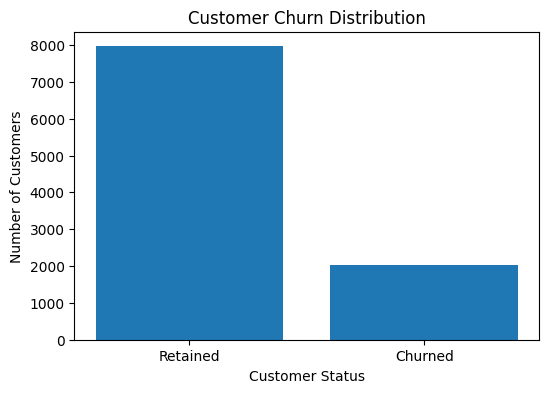

In [7]:
churn_counts = df_model["Exited"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Retained", "Churned"],
        [churn_counts[0], churn_counts[1]])

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

### Finding
20.37% of customers in the dataset churned, while 79.63% were retained. This establishes the baseline churn rate for subsequent segment analysis.

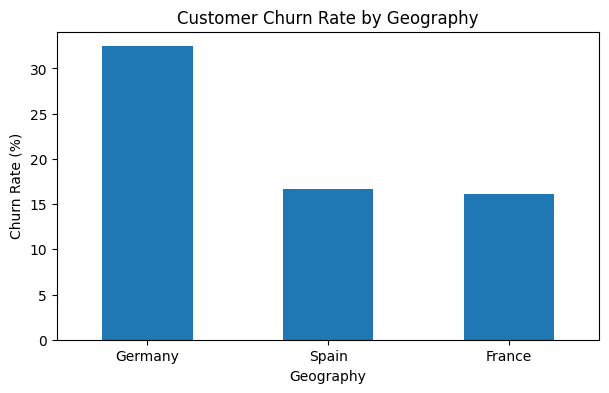

In [8]:
geo_churn = (
    df_model.groupby("Geography")["Exited"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
geo_churn.plot(kind="bar")

plt.title("Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding
Germany has the highest churn rate at 32.44%, approximately twice the churn rates observed in Spain and France.

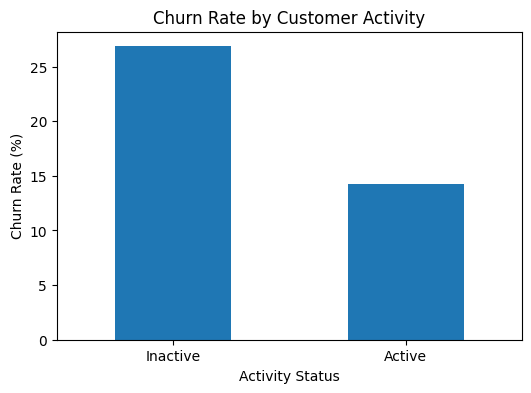

In [9]:
activity_churn = (
    df_model.groupby("IsActiveMember")["Exited"]
    .mean()
    .mul(100)
)

activity_churn.index = ["Inactive", "Active"]

plt.figure(figsize=(6, 4))
activity_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Activity")
plt.xlabel("Activity Status")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding
Inactive customers have a churn rate of 26.85%, compared with 14.27% among active customers, suggesting customer engagement may be an important factor associated with retention.

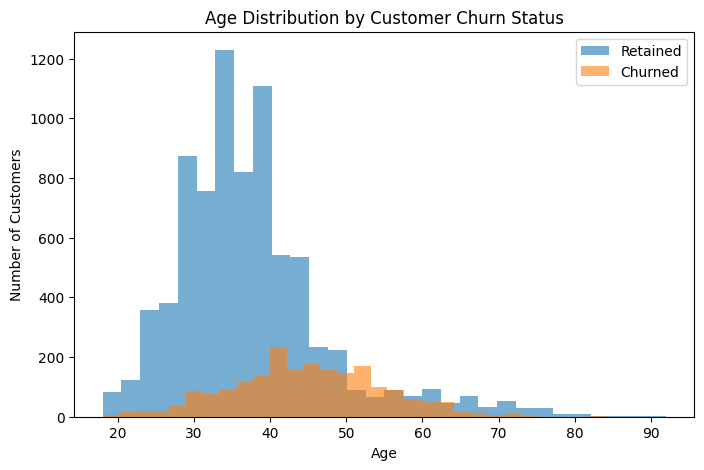

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_model[df_model["Exited"] == 0]["Age"],
    bins=30,
    alpha=0.6,
    label="Retained"
)

plt.hist(
    df_model[df_model["Exited"] == 1]["Age"],
    bins=30,
    alpha=0.6,
    label="Churned"
)

plt.title("Age Distribution by Customer Churn Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

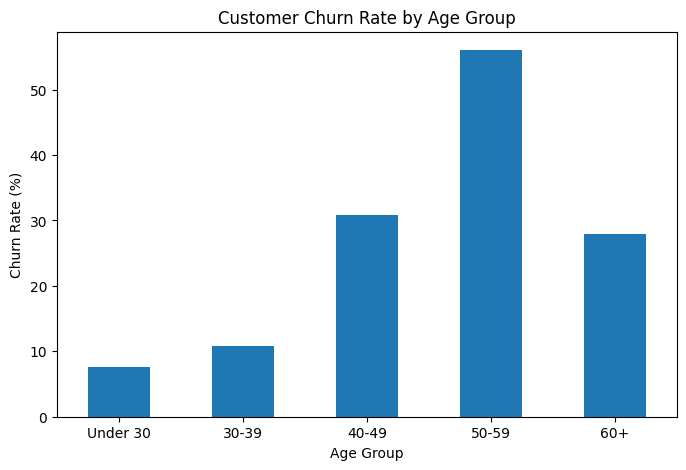

In [11]:
# Create age groups
df_model["AgeGroup"] = pd.cut(
    df_model["Age"],
    bins=[17, 29, 39, 49, 59, 100],
    labels=["Under 30", "30-39", "40-49", "50-59", "60+"]
)

age_churn = (
    df_model.groupby("AgeGroup", observed=False)["Exited"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))
age_churn.plot(kind="bar")

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding
Churn varies substantially by age. Customers aged 50–59 have the highest churn rate at approximately 56%, followed by customers aged 40–49 at approximately 31%. Customers under 30 have the lowest churn rate at approximately 8%, indicating that middle-aged customers represent a particularly important retention segment.

In [12]:
product_churn = (
    df_model.groupby("NumOfProducts")["Exited"]
    .agg(["count", "sum", "mean"])
)

product_churn.columns = [
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

product_churn["Churn Rate"] *= 100

product_churn

,Total Customers,Churned Customers,Churn Rate
NumOfProducts,,,
1,5084,1409,27.714398
2,4590,348,7.581699
3,266,220,82.706767
4,60,60,100.000000


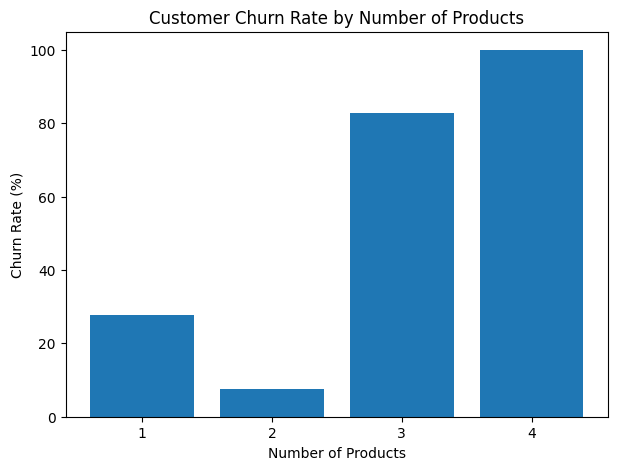

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    product_churn.index.astype(str),
    product_churn["Churn Rate"]
)

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

### Finding
Customers holding two products have the lowest churn rate at approximately 8%, compared with approximately 28% among customers holding one product. Churn is extremely high among customers with three or four products; however, these groups contain relatively few customers, so the result should be interpreted cautiously rather than assuming that additional products cause churn.

## 3. Correlation Analysis

Correlation analysis was used to examine the relationships between numeric customer attributes and churn. Correlation indicates association and should not be interpreted as evidence of causation.

In [15]:
import numpy as np
numeric_df = df_model.select_dtypes(include=np.number)

correlation_with_churn = (
    numeric_df.corr()["Exited"]
    .drop("Exited")
    .sort_values(key=abs, ascending=False)
)

correlation_with_churn

,Exited
Age,0.285323
IsActiveMember,-0.156128
Balance,0.118533
NumOfProducts,-0.047820
CreditScore,-0.027094
Tenure,-0.014001
EstimatedSalary,0.012097
HasCrCard,-0.007138


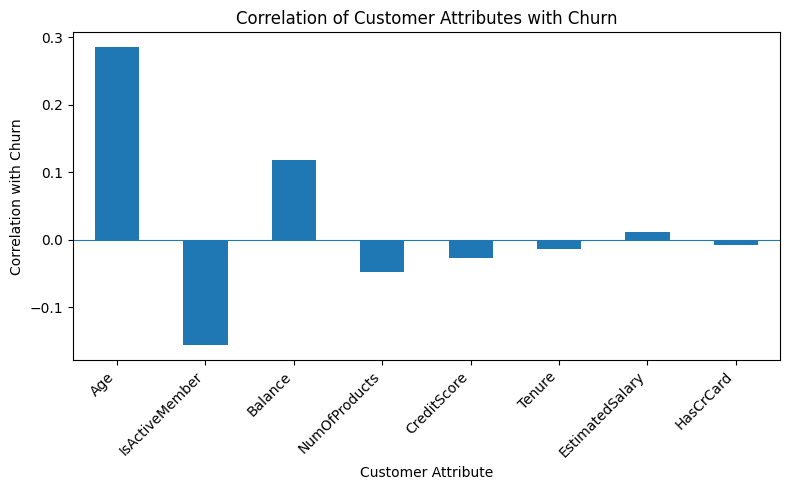

In [16]:
plt.figure(figsize=(8, 5))

correlation_with_churn.plot(kind="bar")

plt.title("Correlation of Customer Attributes with Churn")
plt.xlabel("Customer Attribute")
plt.ylabel("Correlation with Churn")
plt.axhline(0, linewidth=0.8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## 4. Predictive Modeling

A classification model was developed to estimate customer churn risk using demographic, financial, and behavioural customer attributes. Customer identifiers were excluded because they do not represent meaningful predictive characteristics.

In [18]:
model_data = df_model.drop(columns=["AgeGroup"])

X = model_data.drop(columns=["Exited"])
y = model_data["Exited"]

X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [19]:
X = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)

X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.preprocessing import StandardScaler

scale_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

scaler = StandardScaler()

X_train[scale_columns] = scaler.fit_transform(
    X_train[scale_columns]
)

X_test[scale_columns] = scaler.transform(
    X_test[scale_columns]
)

In [22]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.808
Precision: 0.589
Recall: 0.187
F1 Score: 0.284
ROC-AUC: 0.775

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



### Random Forest

Because the baseline logistic regression demonstrated low recall for churned customers, a Random Forest classifier was evaluated to capture potentially nonlinear relationships and interactions between customer attributes.

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=4, min_samples_split=10,
                       n_estimators=300, random_state=42)

In [26]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [27]:
print("Random Forest Performance")
print("-------------------------")

print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Precision:", round(precision_score(y_test, rf_pred), 3))
print("Recall:", round(recall_score(y_test, rf_pred), 3))
print("F1 Score:", round(f1_score(y_test, rf_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Performance
-------------------------
Accuracy: 0.834
Precision: 0.578
Recall: 0.673
F1 Score: 0.622
ROC-AUC: 0.865

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.58      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.83      0.84      2000



### Model Comparison

Random Forest substantially outperformed the baseline Logistic Regression model. While Logistic Regression achieved 80.8% accuracy, it identified only 18.7% of customers who actually churned.

The Random Forest model increased churn recall to 67.3% while achieving 83.4% overall accuracy and an ROC-AUC of 0.865. This indicates a considerably stronger ability to distinguish between customers who are likely to churn and those who are likely to remain.

Random Forest was therefore selected as the preferred model for further analysis.

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Age,0.330569
4,NumOfProducts,0.212582
3,Balance,0.118121
7,EstimatedSalary,0.075606
0,CreditScore,0.072021
6,IsActiveMember,0.054474
8,Geography_Germany,0.053956
2,Tenure,0.040744
10,Gender_Male,0.022285
9,Geography_Spain,0.009887


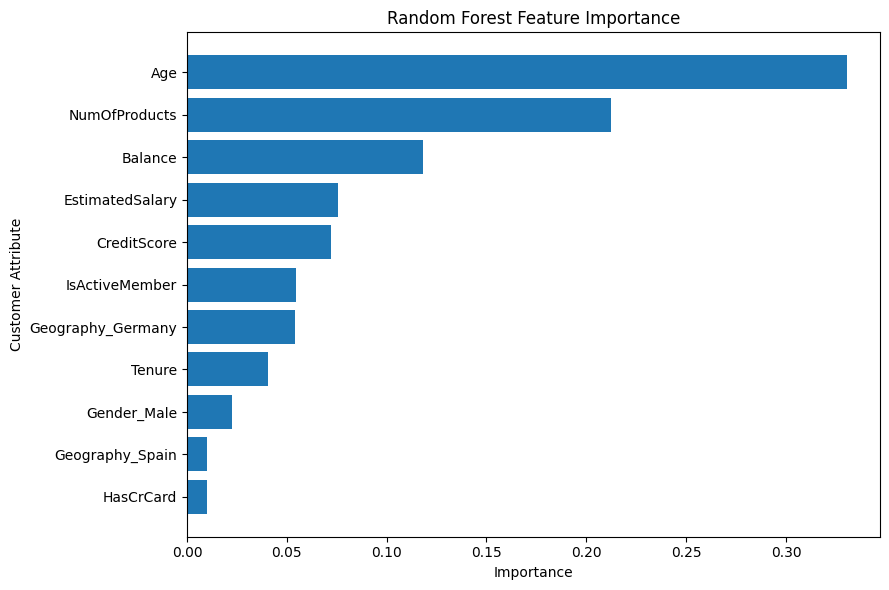

In [29]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Customer Attribute")

plt.tight_layout()
plt.show()

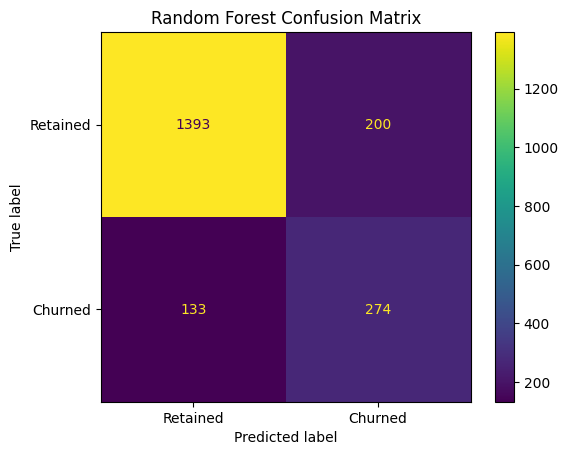

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Retained", "Churned"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

### Model Interpretation

The Random Forest model correctly identified 274 of the 407 customers who churned in the test set, corresponding to a churn recall of 67.3%. It missed 133 churned customers and incorrectly flagged 200 retained customers as potential churners.

Feature importance indicates that age was the most influential variable in the model, followed by number of products and account balance. Customer activity status and geography also contributed to predictions.

These model results are consistent with several patterns identified during exploratory SQL and Python analysis. However, feature importance represents predictive contribution rather than causation and does not indicate the direction of an individual feature's effect.

## 5. Key Findings and Business Recommendations

### Key Findings

- Overall customer churn was **20.37%**.
- Customers in **Germany had a 32.44% churn rate**, approximately twice the rates observed in France and Spain.
- **Inactive customers churned at 26.85%**, compared with 14.27% among active customers.
- Churn varied substantially by age. Customers aged **50–59 recorded the highest churn rate at 56.04%**.
- Customers with two products had substantially lower churn than customers with one product. Customers with three or four products showed extremely high churn, although these groups contained relatively few customers and should therefore be interpreted cautiously.
- Credit-card ownership and tenure showed relatively limited differences in churn when examined independently.
- The Random Forest model achieved **83.4% accuracy, 67.3% churn recall, and a ROC-AUC of 0.865**, substantially outperforming the baseline Logistic Regression model in identifying churned customers.

### Business Recommendations

1. **Prioritize high-risk customers for retention outreach.** Use churn-risk scores to identify customers for proactive engagement rather than applying retention campaigns to the entire customer base.

2. **Investigate declining customer engagement.** Inactive customers experienced substantially higher churn. The bank should examine opportunities to increase meaningful account engagement through relevant services, communications, or personalized offers.

3. **Investigate the German customer experience.** Germany's substantially higher churn warrants further analysis of pricing, service quality, product-market fit, competitive conditions, and customer experience before implementing geography-specific interventions.

4. **Develop targeted strategies for older customer segments.** Customers aged 40–59 demonstrated elevated churn, particularly those aged 50–59. Further customer research should identify the needs and friction points affecting these segments.

5. **Review product relationships.** The strong relationship between product count and churn warrants investigation into product combinations, cross-selling practices, fees, and customer experience. The very small three- and four-product groups should not be used alone to draw causal conclusions.

### Limitations

The analysis is based on a historical public dataset and identifies associations rather than causal relationships. The dataset also lacks potentially important variables such as transaction behaviour, customer-service interactions, product types, fees, complaints, satisfaction measures, and time-series activity. Model performance should therefore be validated on current operational data before being used for real-world retention decisions.